**<center><font size=5>Deteksi Tumor Otak Menggunakan CNN</font></center>**
***
**author**: Taufik Hidayat

**date**: 10 Juli 2023

**Table of Contents**
- <a href='#intro'>1. Gambaran Proyek dan Tujuan</a> 
    - <a href='#dataset'>1.1. Deskripsi Kumpulan Data</a>
    - <a href='#tumor'>1.2. Apa itu Tumor Otak?</a>
- <a href='#env'>2.  Menyiapkan Lingkungan</a>
- <a href='#import'>3. Impor Data dan Pra-pemrosesang</a>
- <a href='#cnn'>4.Model CNN</a>
    - <a href='#aug'>4.1. Augmentasi Data</a>
        - <a href='#demo'>4.1.1. Demo</a>
        - <a href='#apply'>4.1.2. Terapkan</a>
    - <a href='#build'>4.2. Model Building</a>
    - <a href='#perf'>4.3. Pembangunan Model</a>
- <a href='#concl'>5. Kesimpulan</a>

# <a id='intro'>1. Gambaran Proyek dan Tujuan</a>

Tujuan utama dari proyek ini adalah membangun model CNN yang dapat mengklasifikasikan apakah subjek memiliki tumor atau tidak berdasarkan pemindaian MRI. Saya menggunakan arsitektur dan bobot model VGG-16 (https://www.kaggle.com/navoneel/brain-mri-images-for-brain-tumor-detection) untuk melatih model ini untuk masalah biner ini. Saya menggunakan metrik akurasi sebagai dasar untuk mengevaluasi performa model yang dapat didefinisikan sebagai:

$\textrm{Akurasi} = \frac{\textrm{Jumlah gambar yang diprediksi dengan benar}}{\textrm{Total jumlah gambar yang diuji}} \times 100\%$

Hasil akhir terlihat sebagai berikut:

| Kumpulan hasil akhir terlihat sebagai berikut: | Akurasi |
|:-:|:-:|
| Kumpulan hasil validasi terlihat* | ~88% |
| Kumpulan hasil pengujian terlihat* | ~80% |
<br>
\* *Catatan: mungkin ada beberapa kesalahpahaman dalam hal nama-nama set, jadi saya ingin menjelaskan apa yang saya maksud dengan test dan validation set:*
* *`Set validasi - adalah set yang digunakan selama pelatihan model untuk menyesuaikan hiperparameter. *
* *`Set pengujian - adalah set kecil yang tidak saya sentuh sama sekali selama seluruh proses pelatihan. Set ini digunakan untuk evaluasi kinerja akhir model.*

## <a id='dataset'>1.1.  Deskripsi Kumpulan Data</a>


Data gambar yang digunakan untuk masalah ini adalah [Gambar MRI Otak untuk Deteksi Tumor Otak](https://www.kaggle.com/navoneel/brain-mri-images-for-brain-tumor-detection).
Data tersebut terdiri dari pemindaian MRI dari dua kelas:

* `NO` - tidak ada tumor, dienkripsi sebagai `0`
* `YES` - tumor, dienkripsi sebagai `1`

Sayangnya, deskripsi kumpulan data tidak menyediakan informasi tentang asal usul pemindaian MRI ini dan sebagainya.

## <a id='tumor'>1.2. Apa itu Tumor Otak?</a>

> Tumor otak terjadi ketika sel-sel abnormal terbentuk di dalam otak. Ada dua jenis utama tumor: tumor ganas (maligna) dan tumor jinak. Tumor ganas dapat dibagi menjadi tumor primer, yang dimulai di dalam otak, dan tumor sekunder, yang telah menyebar dari tempat lain, yang dikenal sebagai tumor metastasis otak. Semua jenis tumor otak dapat menyebabkan gejala yang bervariasi tergantung pada bagian otak yang terlibat. Gejala ini dapat mencakup sakit kepala, kejang, masalah penglihatan, muntah, dan perubahan mental. Sakit kepala biasanya lebih parah di pagi hari dan hilang setelah muntah. Gejala lainnya dapat meliputi kesulitan berjalan, berbicara, atau dengan sensasi. Seiring berkembangnya penyakit, kehilangan kesadaran dapat terjadi.
>
> ![](https://upload.wikimedia.org/wikipedia/commons/5/5f/Hirnmetastase_MRT-T1_KM.jpg)
>
> *
Metastasis otak pada hemisfer serebral kanan dari kanker paru-paru, terlihat pada gambaran pemindaian resonansi magnetik (MRI).*

Source: [Wikipedia](https://en.wikipedia.org/wiki/Brain_tumor)

# <a id='env'>2. Menyiapkan Lingkungan</a>

In [ ]:
from IPython.display import clear_output
!pip install imutils
clear_output()

In [ ]:
import numpy as np 
from tqdm import tqdm
import cv2
import os
import shutil
import itertools
import imutils
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
from plotly import tools

from keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg16 import VGG16, preprocess_input
from keras import layers
from keras.models import Model, Sequential
from keras.optimizers import Adam, RMSprop
from keras.callbacks import EarlyStopping

init_notebook_mode(connected=True)
RANDOM_SEED = 123

Using TensorFlow backend.
/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning:

Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.

/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning:

Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.

/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning:

Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.

/opt/conda/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:519: FutureWarning:

Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1

Saat ini semua gambar berada dalam satu folder dengan subfolder yes dan no. Saya akan membagi data menjadi folder train, val, dan test yang akan memudahkan pekerjaan saya. Hierarchy folder baru akan terlihat sebagai berikut:

In [ ]:
!apt-get install tree
clear_output()
# create new folders
!mkdir TRAIN TEST VAL TRAIN/YES TRAIN/NO TEST/YES TEST/NO VAL/YES VAL/NO
!tree -d

/bin/sh: 1: tree: not found


In [ ]:
IMG_PATH = '../input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/'
# split the data by train/val/test
for CLASS in os.listdir(IMG_PATH):
    if not CLASS.startswith('.'):
        IMG_NUM = len(os.listdir(IMG_PATH + CLASS))
        for (n, FILE_NAME) in enumerate(os.listdir(IMG_PATH + CLASS)):
            img = IMG_PATH + CLASS + '/' + FILE_NAME
            if n < 5:
                shutil.copy(img, 'TEST/' + CLASS.upper() + '/' + FILE_NAME)
            elif n < 0.8*IMG_NUM:
                shutil.copy(img, 'TRAIN/'+ CLASS.upper() + '/' + FILE_NAME)
            else:
                shutil.copy(img, 'VAL/'+ CLASS.upper() + '/' + FILE_NAME)

# <a id='import'>3. Impor Data dan Pra-pemrosesan</a>

In [ ]:
def load_data(dir_path, img_size=(100,100)):
    """
    Load resized images as np.arrays to workspace
    """
    X = []
    y = []
    i = 0
    labels = dict()
    for path in tqdm(sorted(os.listdir(dir_path))):
        if not path.startswith('.'):
            labels[i] = path
            for file in os.listdir(dir_path + path):
                if not file.startswith('.'):
                    img = cv2.imread(dir_path + path + '/' + file)
                    X.append(img)
                    y.append(i)
            i += 1
    X = np.array(X)
    y = np.array(y)
    print(f'{len(X)} images loaded from {dir_path} directory.')
    return X, y, labels



def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.figure(figsize = (6,6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    cm = np.round(cm,2)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

In [ ]:
TRAIN_DIR = 'TRAIN/'
TEST_DIR = 'TEST/'
VAL_DIR = 'VAL/'
IMG_SIZE = (224,224)

# use predefined function to load the image data into workspace
X_train, y_train, labels = load_data(TRAIN_DIR, IMG_SIZE)
X_test, y_test, _ = load_data(TEST_DIR, IMG_SIZE)
X_val, y_val, _ = load_data(VAL_DIR, IMG_SIZE)

100%|██████████| 2/2 [00:00<00:00, 18.46it/s]

193 images loaded from TRAIN/ directory.
10 images loaded from TEST/ directory.
50 images loaded from VAL/ directory.


Mari kita lihat distribusi kelas di antara set-set tersebut:

In [ ]:
y = dict()
y[0] = []
y[1] = []
for set_name in (y_train, y_val, y_test):
    y[0].append(np.sum(set_name == 0))
    y[1].append(np.sum(set_name == 1))

trace0 = go.Bar(
    x=['Train Set', 'Validation Set', 'Test Set'],
    y=y[0],
    name='No',
    marker=dict(color='#33cc33'),
    opacity=0.7
)
trace1 = go.Bar(
    x=['Train Set', 'Validation Set', 'Test Set'],
    y=y[1],
    name='Yes',
    marker=dict(color='#ff3300'),
    opacity=0.7
)
data = [trace0, trace1]
layout = go.Layout(
    title='Count of classes in each set',
    xaxis={'title': 'Set'},
    yaxis={'title': 'Count'}
)
fig = go.Figure(data, layout)
iplot(fig)

In [ ]:
def plot_samples(X, y, labels_dict, n=50):
    """
    Creates a gridplot for desired number of images (n) from the specified set
    """
    for index in range(len(labels_dict)):
        imgs = X[np.argwhere(y == index)][:n]
        j = 10
        i = int(n/j)

        plt.figure(figsize=(15,6))
        c = 1
        for img in imgs:
            plt.subplot(i,j,c)
            plt.imshow(img[0])

            plt.xticks([])
            plt.yticks([])
            c += 1
        plt.suptitle('Tumor: {}'.format(labels_dict[index]))
        plt.show()

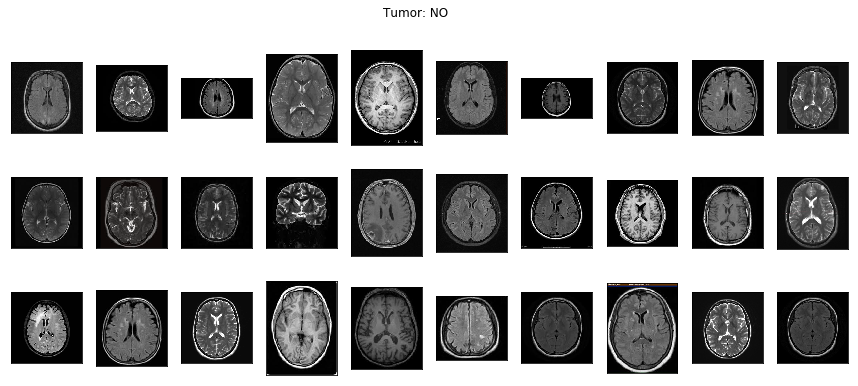

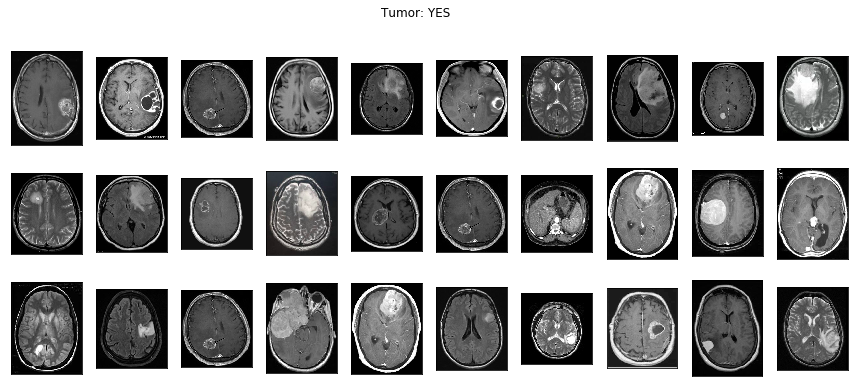

In [ ]:
plot_samples(X_train, y_train, labels, 30)

Seperti yang Anda lihat, gambar-gambar memiliki lebar dan tinggi yang berbeda serta ukuran "sudut hitam" yang berbeda pula. Karena ukuran gambar untuk lapisan masukan VGG-16 adalah (224,224), beberapa gambar lebar mungkin terlihat aneh setelah diubah ukurannya. Berikut ini adalah histogram distribusi rasio (rasio = lebar/tinggi):

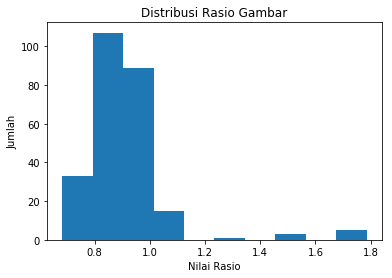

In [ ]:
RATIO_LIST = []
for set in (X_train, X_test, X_val):
    for img in set:
        RATIO_LIST.append(img.shape[1]/img.shape[0])
        
plt.hist(RATIO_LIST)
plt.title('Distribusi Rasio Gambar')
plt.xlabel('Nilai Rasio')
plt.ylabel('Jumlah')
plt.show()



Langkah pertama dari "normalisasi" adalah memotong otak dari gambar-gambar tersebut. Saya menggunakan teknik yang dijelaskan dengan baik dalam blog  [pyimagesearch](https://www.pyimagesearch.com/2016/04/11/finding-extreme-points-in-contours-with-opencv/) dan sangat disarankan untuk mempelajari lebih lanjut tentangnya.

In [ ]:
def crop_imgs(set_name, add_pixels_value=0):
    """
    Finds the extreme points on the image and crops the rectangular out of them
    """
    set_new = []
    for img in set_name:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)

        # threshold the image, then perform a series of erosions +
        # dilations to remove any small regions of noise
        thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
        thresh = cv2.erode(thresh, None, iterations=2)
        thresh = cv2.dilate(thresh, None, iterations=2)

        # find contours in thresholded image, then grab the largest one
        cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cnts = imutils.grab_contours(cnts)
        c = max(cnts, key=cv2.contourArea)

        # find the extreme points
        extLeft = tuple(c[c[:, :, 0].argmin()][0])
        extRight = tuple(c[c[:, :, 0].argmax()][0])
        extTop = tuple(c[c[:, :, 1].argmin()][0])
        extBot = tuple(c[c[:, :, 1].argmax()][0])

        ADD_PIXELS = add_pixels_value
        new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()
        set_new.append(new_img)

    return np.array(set_new)


Mari kita lihat contoh apa yang akan dilakukan oleh fungsi ini dengan pemindaian MRI:

In [ ]:
img = cv2.imread('../input/brain-mri-images-for-brain-tumor-detection/brain_tumor_dataset/yes/Y108.jpg')
img = cv2.resize(
            img,
            dsize=IMG_SIZE,
            interpolation=cv2.INTER_CUBIC
        )
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 0)

# threshold the image, then perform a series of erosions +
# dilations to remove any small regions of noise
thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
thresh = cv2.erode(thresh, None, iterations=2)
thresh = cv2.dilate(thresh, None, iterations=2)

# find contours in thresholded image, then grab the largest one
cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)
c = max(cnts, key=cv2.contourArea)

# find the extreme points
extLeft = tuple(c[c[:, :, 0].argmin()][0])
extRight = tuple(c[c[:, :, 0].argmax()][0])
extTop = tuple(c[c[:, :, 1].argmin()][0])
extBot = tuple(c[c[:, :, 1].argmax()][0])

# add contour on the image
img_cnt = cv2.drawContours(img.copy(), [c], -1, (0, 255, 255), 4)

# add extreme points
img_pnt = cv2.circle(img_cnt.copy(), extLeft, 8, (0, 0, 255), -1)
img_pnt = cv2.circle(img_pnt, extRight, 8, (0, 255, 0), -1)
img_pnt = cv2.circle(img_pnt, extTop, 8, (255, 0, 0), -1)
img_pnt = cv2.circle(img_pnt, extBot, 8, (255, 255, 0), -1)

# crop
ADD_PIXELS = 0
new_img = img[extTop[1]-ADD_PIXELS:extBot[1]+ADD_PIXELS, extLeft[0]-ADD_PIXELS:extRight[0]+ADD_PIXELS].copy()

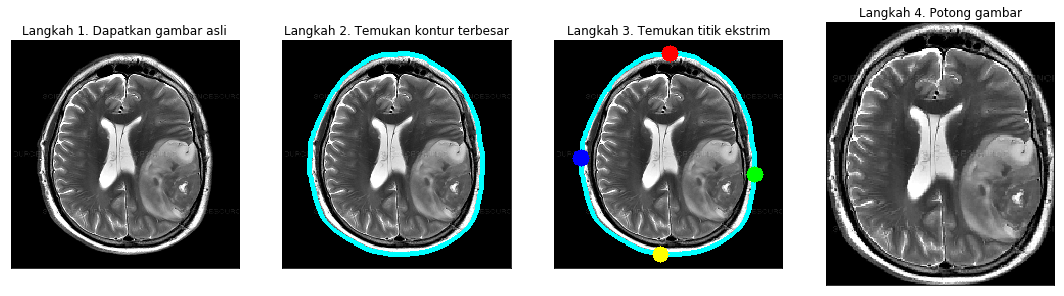

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(141)
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.title('Langkah 1. Dapatkan gambar asli')

plt.subplot(142)
plt.imshow(img_cnt)
plt.xticks([])
plt.yticks([])
plt.title('Langkah 2. Temukan kontur terbesar')

plt.subplot(143)
plt.imshow(img_pnt)
plt.xticks([])
plt.yticks([])
plt.title('Langkah 3. Temukan titik ekstrim')

plt.subplot(144)
plt.imshow(new_img)
plt.xticks([])
plt.yticks([])
plt.title('Langkah 4. Potong gambar')

plt.tight_layout()
plt.show()

In [ ]:
# apply this for each set
X_train_crop = crop_imgs(set_name=X_train)
X_val_crop = crop_imgs(set_name=X_val)
X_test_crop = crop_imgs(set_name=X_test)

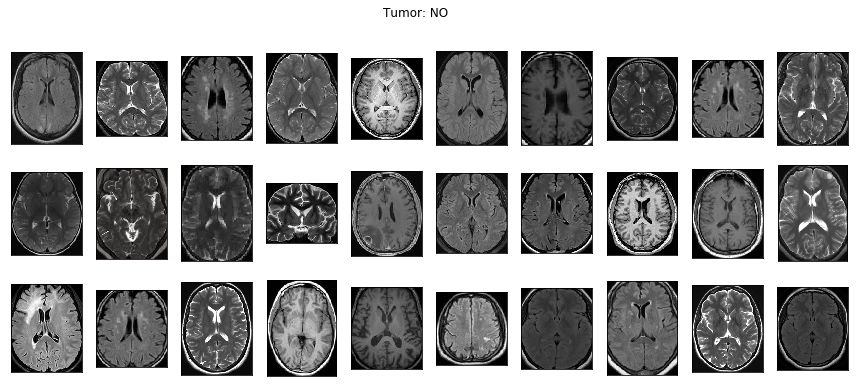

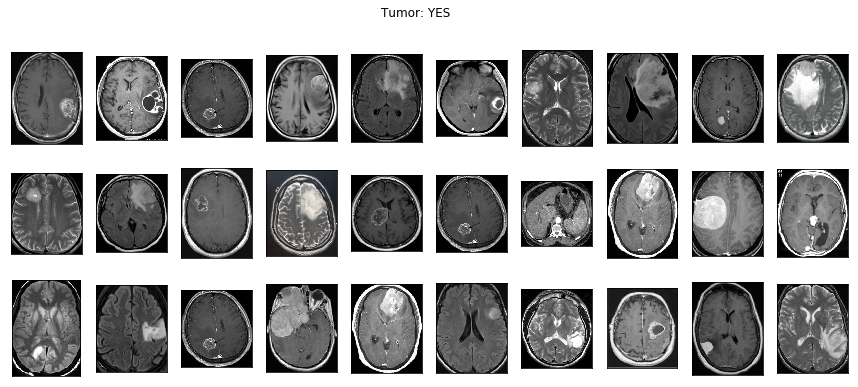

In [ ]:
plot_samples(X_train_crop, y_train, labels, 30)

In [ ]:
def save_new_images(x_set, y_set, folder_name):
    i = 0
    for (img, imclass) in zip(x_set, y_set):
        if imclass == 0:
            cv2.imwrite(folder_name+'NO/'+str(i)+'.jpg', img)
        else:
            cv2.imwrite(folder_name+'YES/'+str(i)+'.jpg', img)
        i += 1

In [ ]:
# saving new images to the folder
!mkdir TRAIN_CROP TEST_CROP VAL_CROP TRAIN_CROP/YES TRAIN_CROP/NO TEST_CROP/YES TEST_CROP/NO VAL_CROP/YES VAL_CROP/NO

save_new_images(X_train_crop, y_train, folder_name='TRAIN_CROP/')
save_new_images(X_val_crop, y_val, folder_name='VAL_CROP/')
save_new_images(X_test_crop, y_test, folder_name='TEST_CROP/')


Langkah berikutnya adalah mengubah ukuran gambar menjadi (224,224) dan menerapkan pra-pemrosesan yang diperlukan untuk masukan model VGG-16.

In [ ]:
def preprocess_imgs(set_name, img_size):
    """
    Resize and apply VGG-15 preprocessing
    """
    set_new = []
    for img in set_name:
        img = cv2.resize(
            img,
            dsize=img_size,
            interpolation=cv2.INTER_CUBIC
        )
        set_new.append(preprocess_input(img))
    return np.array(set_new)

In [ ]:
X_train_prep = preprocess_imgs(set_name=X_train_crop, img_size=IMG_SIZE)
X_test_prep = preprocess_imgs(set_name=X_test_crop, img_size=IMG_SIZE)
X_val_prep = preprocess_imgs(set_name=X_val_crop, img_size=IMG_SIZE)

In [ ]:
# plot_samples(X_train_prep, y_train, labels, 30)

# <a id='cnn'>4. Model CNN</a>


Saya menggunakan  [Transfer Learning](https://towardsdatascience.com/keras-transfer-learning-for-beginners-6c9b8b7143e) dengan arsitektur dan bobot VGG-16 sebagai model dasar.


## <a id='aug'>4.1. Augmentasi Data</a>


Karena saya memiliki kumpulan data yang kecil, saya menggunakan teknik yang disebut [Augmentasi Data](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html) yang membantu "memperluas" ukuran set pelatihan.


### <a id='demo'>4.1.1. Demo</a>


Berikut adalah contoh dari satu gambar bagaimana augmentasi terlihat.

In [ ]:
# set the paramters we want to change randomly
demo_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    rescale=1./255,
    shear_range=0.05,
    brightness_range=[0.1, 1.5],
    horizontal_flip=True,
    vertical_flip=True
)

In [ ]:
os.mkdir('preview')
x = X_train_crop[0]  
x = x.reshape((1,) + x.shape) 

i = 0
for batch in demo_datagen.flow(x, batch_size=1, save_to_dir='preview', save_prefix='aug_img', save_format='jpg'):
    i += 1
    if i > 20:
        break 

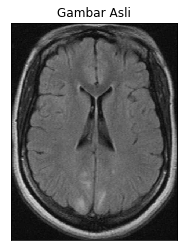

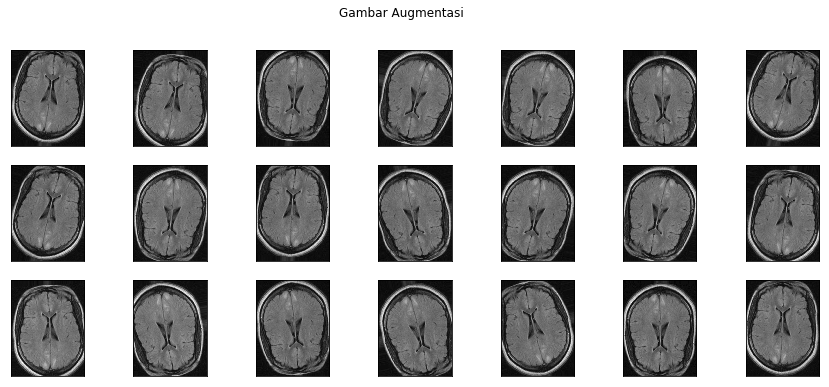

In [ ]:
plt.imshow(X_train_crop[0])
plt.xticks([])
plt.yticks([])
plt.title('Gambar Asli')
plt.show()

plt.figure(figsize=(15,6))
i = 1
for img in os.listdir('preview/'):
    img = cv2.cv2.imread('preview/' + img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(3,7,i)
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    i += 1
    if i > 3*7:
        break
plt.suptitle('Gambar Augmentasi')
plt.show()

In [ ]:
!rm -rf preview/

### <a id='apply'>4.1.2. Terapkan</a>

In [ ]:
TRAIN_DIR = 'TRAIN_CROP/'
VAL_DIR = 'VAL_CROP/'

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.5, 1.5],
    horizontal_flip=True,
    vertical_flip=True,
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    color_mode='rgb',
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    seed=RANDOM_SEED
)


validation_generator = test_datagen.flow_from_directory(
    VAL_DIR,
    color_mode='rgb',
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode='binary',
    seed=RANDOM_SEED
)

Found 193 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


## <a id='build'>4.2. Model Building</a>

In [ ]:
# load base model
vgg16_weight_path = '../input/keras-pretrained-models/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'
base_model = VGG16(
    weights=vgg16_weight_path,
    include_top=False, 
    input_shape=IMG_SIZE + (3,)
)

In [ ]:
NUM_CLASSES = 1

model = Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(NUM_CLASSES, activation='sigmoid'))

model.layers[0].trainable = False

model.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(lr=1e-4),
    metrics=['accuracy']
)

model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Model)                (None, 7, 7, 512)         14714688  
_________________________________________________________________
flatten_1 (Flatten)          (None, 25088)             0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 25088)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 25089     
Total params: 14,739,777
Trainable params: 25,089
Non-trainable params: 14,714,688
_________________________________________________________________


In [ ]:
EPOCHS = 30
es = EarlyStopping(
    monitor='val_acc', 
    mode='max',
    patience=6
)

history = model.fit_generator(
    train_generator,
    steps_per_epoch=50,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=25,
    callbacks=[es]
)

Epoch 1/30
50/50 [==============================] - 26s 521ms/step - loss: 3.0413 - acc: 0.6655 - val_loss: 2.3925 - val_acc: 0.7405
Epoch 2/30
50/50 [==============================] - 23s 458ms/step - loss: 2.0978 - acc: 0.7699 - val_loss: 1.9720 - val_acc: 0.7278
Epoch 3/30
50/50 [==============================] - 22s 450ms/step - loss: 1.7213 - acc: 0.7986 - val_loss: 1.8741 - val_acc: 0.7563
Epoch 4/30
50/50 [==============================] - 23s 462ms/step - loss: 1.5517 - acc: 0.8186 - val_loss: 1.6756 - val_acc: 0.7417
Epoch 5/30
50/50 [==============================] - 23s 462ms/step - loss: 1.4120 - acc: 0.8266 - val_loss: 1.4091 - val_acc: 0.7722
Epoch 6/30
50/50 [==============================] - 23s 458ms/step - loss: 1.1615 - acc: 0.8571 - val_loss: 1.2075 - val_acc: 0.7753
Epoch 7/30
50/50 [==============================] - 22s 438ms/step - loss: 1.0621 - acc: 0.8739 - val_loss: 1.6180 - val_acc: 0.7753
Epoch 8/30
50/50 [==============================] - 24s 470ms/step - 

## <a id='perf'>4.3. Pembangunan Model</a>

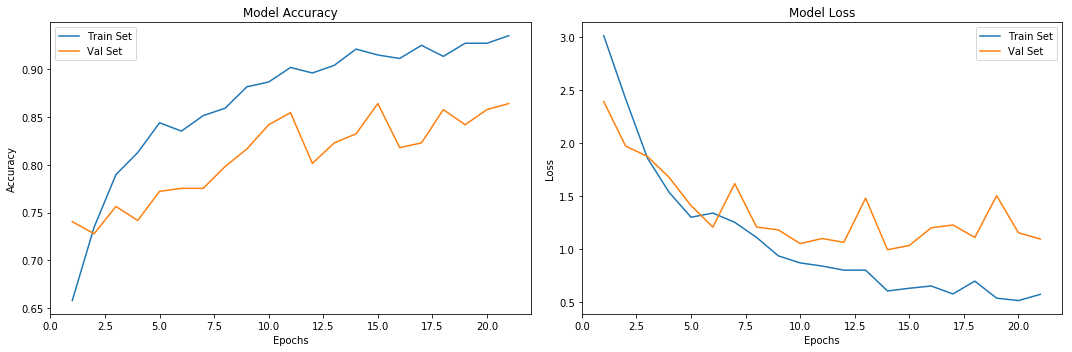

In [ ]:
# plot model performance
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(history.epoch) + 1)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

**TABEL AKURASI MODEL**

Val Accuracy = 0.88


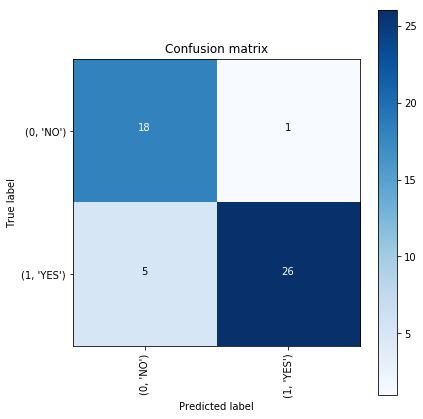

In [ ]:
# validate on val set
predictions = model.predict(X_val_prep)
predictions = [1 if x>0.5 else 0 for x in predictions]

accuracy = accuracy_score(y_val, predictions)
print('Val Accuracy = %.2f' % accuracy)

confusion_mtx = confusion_matrix(y_val, predictions) 
cm = plot_confusion_matrix(confusion_mtx, classes = list(labels.items()), normalize=False)

**TABEL MATRIKS KEPUTUSAN :**

Test Accuracy = 0.70


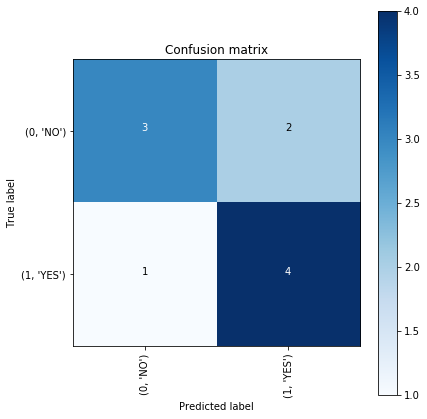

In [ ]:
# validate on test set
predictions = model.predict(X_test_prep)
predictions = [1 if x>0.5 else 0 for x in predictions]

accuracy = accuracy_score(y_test, predictions)
print('Test Accuracy = %.2f' % accuracy)

confusion_mtx = confusion_matrix(y_test, predictions) 
cm = plot_confusion_matrix(confusion_mtx, classes = list(labels.items()), normalize=False)

**TABEL PARAMETER MODEL**

In [ ]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Model)                (None, 7, 7, 512)         14714688  
_________________________________________________________________
flatten_1 (Flatten)          (None, 25088)             0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 25088)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 25089     
Total params: 14,739,777
Trainable params: 25,089
Non-trainable params: 14,714,688
_________________________________________________________________


Sekarang mari kita lihat gambar-gambar dari set pengujian yang salah diklasifikasikan:

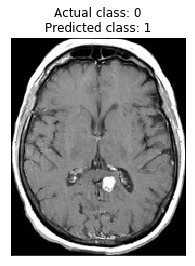

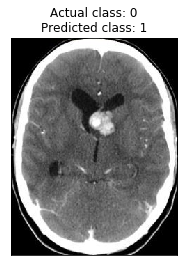

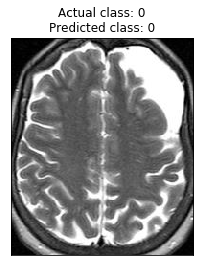

In [ ]:
ind_list = np.argwhere((y_test == predictions) == False)[:, -1]
if ind_list.size == 0:
    print('There are no missclassified images.')
else:
    for i in ind_list:
        plt.figure()
        plt.imshow(X_test_crop[i])
        plt.xticks([])
        plt.yticks([])
        plt.title(f'Actual class: {y_val[i]}\nPredicted class: {predictions[i]}')
        plt.show()

Pemindaian pertama terlihat sedikit membingungkan - apa itu titik terang di tengah?  Saya bisa melihat dengan jelas mengapa model mengklasifikasikannya sebagai Tumor.

# <a id='concl'>5. Kesimpulan</a>

Proyek ini merupakan kombinasi dari masalah klasifikasi model CNN (untuk memprediksi apakah subjek memiliki tumor otak atau tidak) dan masalah Visi Komputer (untuk mengotomatisasi proses pemotongan otak dari pemindaian MRI). Akurasi akhirnya jauh lebih tinggi daripada 50% baseline (tebakan acak). Namun, akurasi tersebut dapat ditingkatkan dengan jumlah gambar latihan yang lebih besar atau melalui penyetelan hiperparameter model.

In [ ]:
# clean up the space
!rm -rf TRAIN TEST VAL TRAIN_CROP TEST_CROP VAL_CROP
# save the model
model.save('2019-06-07_VGG_model.h5')